In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# Cargar el dataset
df = pd.read_csv('diabetes.csv')

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas del dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               76

# Descripción de las variables:
- Pregnancies: Número de embarazos

- Glucose: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa

- BloodPressure: Presión arterial diastólica (mm Hg)

- SkinThickness: Grosor del pliegue cutáneo del tríceps (mm)

- Insulin: Insulina sérica de 2 horas (mu U/ml)

- BMI: Índice de masa corporal (peso en kg/(altura en m)^2)

- DiabetesPedigreeFunction: Función que califica la probabilidad de diabetes basada en antecedentes familiares

- Age: Edad en años

- Outcome: Variable objetivo (1 = diabetes, 0 = no diabetes)

- Contexto: Este conjunto de datos contiene información médica de pacientes y busca predecir si una persona tiene diabetes basándose en diversas mediciones clínicas.

In [3]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(df.describe())

# Información sobre valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min     

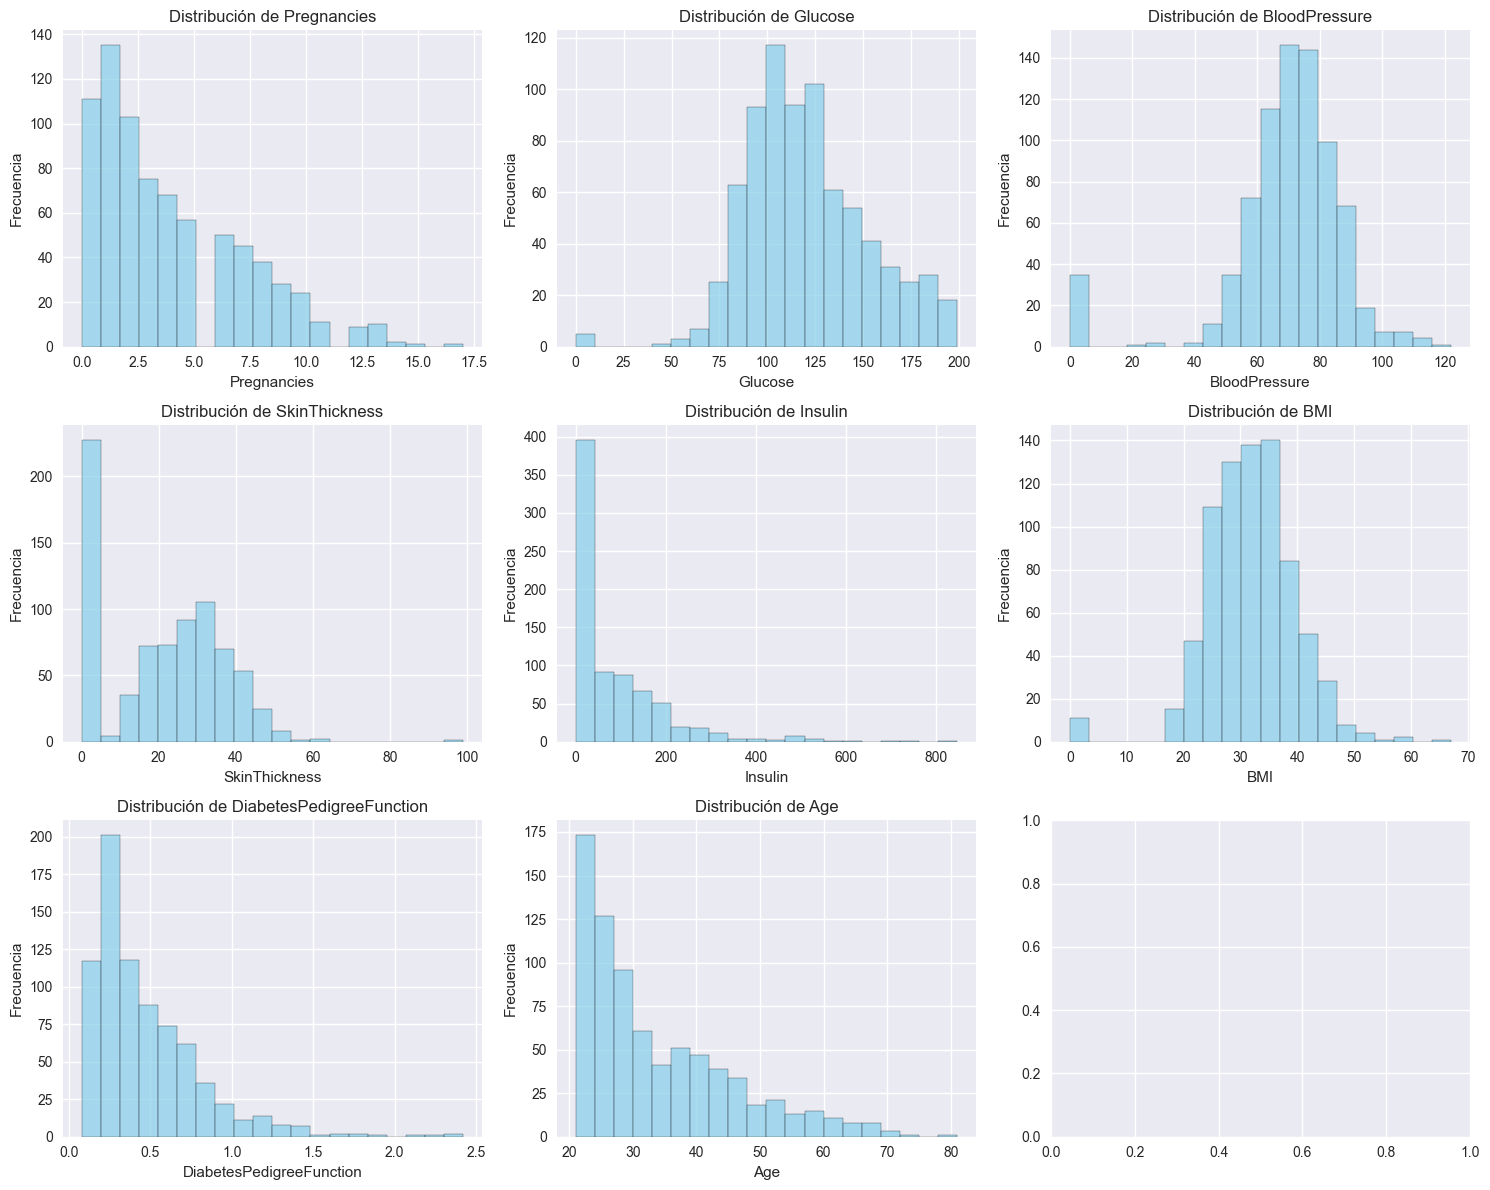

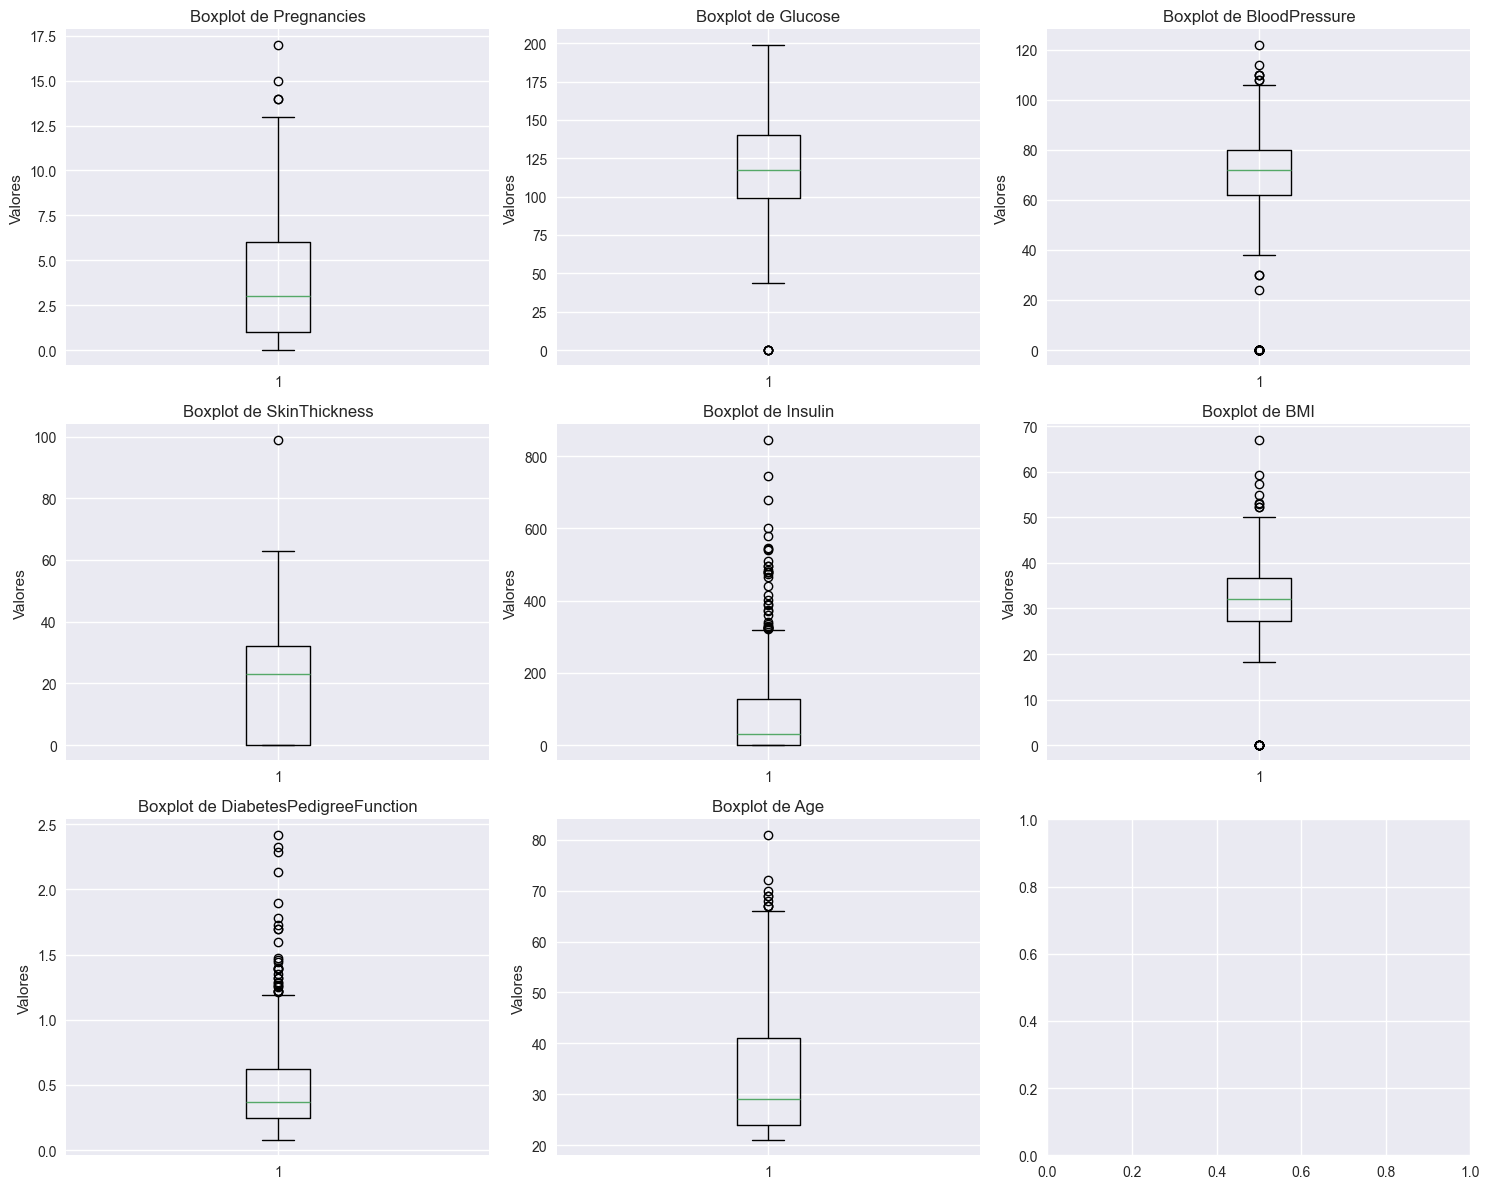

In [ ]:
# Visualización de distribuciones

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Histogramas para cada variable
variables = df.columns[:-1]
for i, col in enumerate(variables):
    axes[i].hist(df[col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Boxplots para identificar outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(variables):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

In [ ]:
# Manejo de valores atípicos y nulos

print("Valores cero por columna (que podrían ser missing):")
for col in variables:
    cero_count = (df[col] == 0).sum()
    if cero_count > 0:
        print(f"{col}: {cero_count} valores cero")

# Reemplazar ceros por NaN en estas columnas
# Glucose, BloodPressure, SkinThickness, Insulin, BMI
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()

for col in columns_to_clean:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Verificar valores nulos después del reemplazo
print("\nValores nulos después de reemplazar ceros:")
print(df_clean.isnull().sum())

# Estrategia para manejar valores nulos: imputación con la mediana
for col in columns_to_clean:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

print("\nValores nulos después de la imputación:")
print(df_clean.isnull().sum())

Valores cero por columna (que podrían ser missing):
Pregnancies: 111 valores cero
Glucose: 5 valores cero
BloodPressure: 35 valores cero
SkinThickness: 227 valores cero
Insulin: 374 valores cero
BMI: 11 valores cero

Valores nulos después de reemplazar ceros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Valores nulos después de la imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\danie\AppData\Local\Temp\ipykernel_2220\2402444878.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
C:\Users\danie\AppData\Local\Temp\ipykernel_2220\2402444878.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

Distribución de clases:
Outcome
0    500
1    268
Name: count, dtype: int64


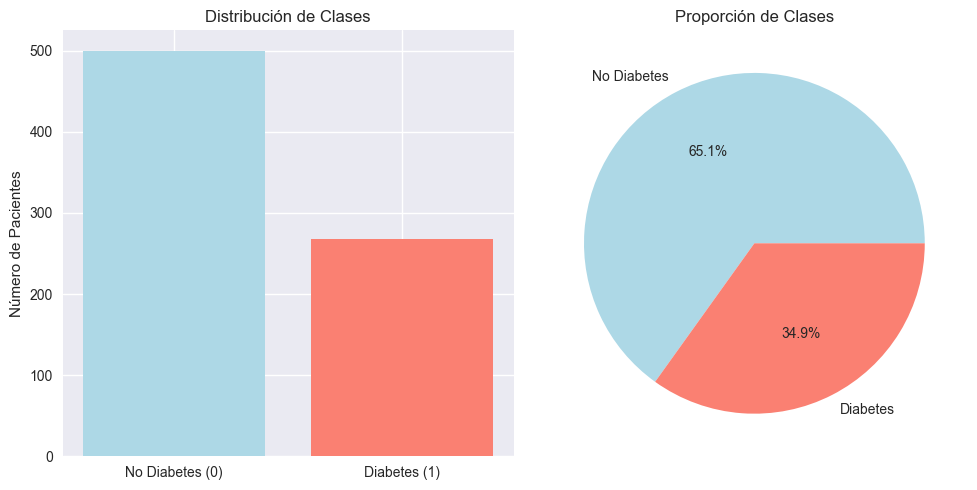


Proporciones:
No Diabetes: 65.10%
Diabetes: 34.90%


In [6]:
# Análisis de balance de clases

class_distribution = df_clean['Outcome'].value_counts()
print("Distribución de clases:")
print(class_distribution)

plt.figure(figsize=(10, 5))

# Gráfico de barras de la distribución de clases
plt.subplot(1, 2, 1)
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], class_distribution.values, 
        color=['lightblue', 'salmon'])
plt.title('Distribución de Clases')
plt.ylabel('Número de Pacientes')

# Gráfico de pie
plt.subplot(1, 2, 2)
plt.pie(class_distribution.values, labels=['No Diabetes', 'Diabetes'], 
        autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Proporción de Clases')

plt.tight_layout()
plt.show()

# Calcular proporciones
total = len(df_clean)
diabetes_ratio = class_distribution[1] / total
no_diabetes_ratio = class_distribution[0] / total

print(f"\nProporciones:")
print(f"No Diabetes: {no_diabetes_ratio:.2%}")
print(f"Diabetes: {diabetes_ratio:.2%}")

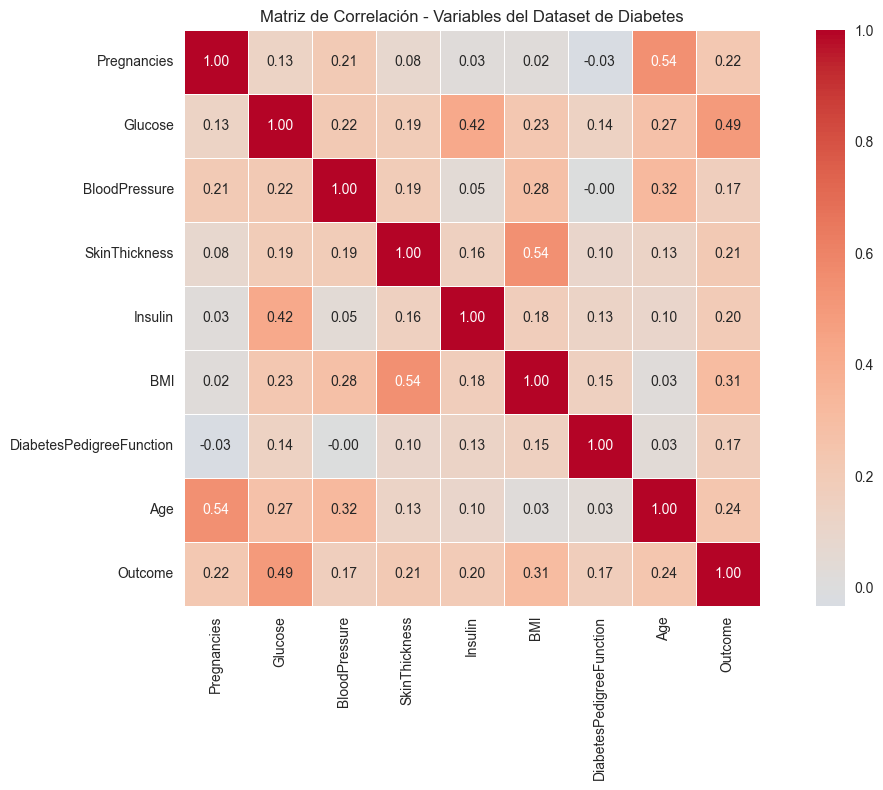


Correlaciones con Outcome (variable objetivo):
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


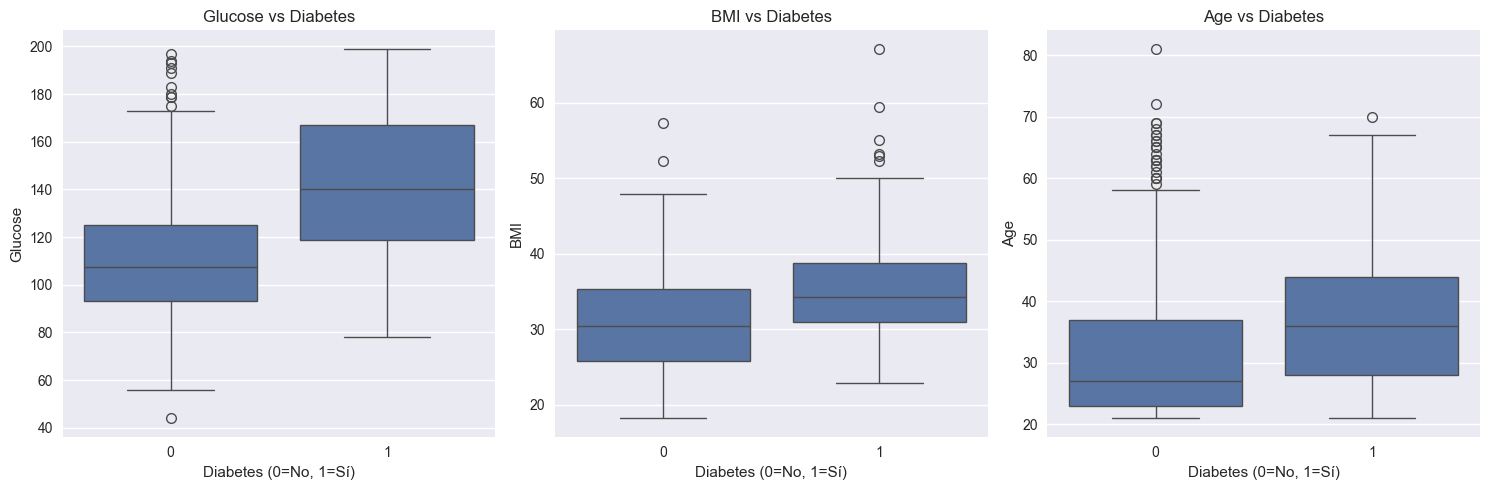

In [ ]:
# Matriz de correlación

correlation_matrix = df_clean.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables del Dataset de Diabetes')
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelaciones con Outcome (variable objetivo):")
outcome_correlations = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_correlations)

# Visualización de relaciones importantes
important_vars = outcome_correlations.index[1:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(important_vars):
    sns.boxplot(x='Outcome', y=var, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{var} vs Diabetes')
    axes[i].set_xlabel('Diabetes (0=No, 1=Sí)')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()